In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
yield_df = pd.read_csv("../data/raw/yield_curve_history.csv")

print(yield_df.shape)
yield_df.head()

(264, 8)


,CurveDate,Currency,Tenor_Years,TenorLabel,Yield,ZeroRate,ForwardRate,DiscountFactor
0,2022-12-30,INR,0.25,3M,0.062896,0.062438,0.067612,0.984866
1,2022-12-30,INR,0.50,6M,0.066424,0.066572,0.067280,0.968356
2,2022-12-30,INR,1.00,1Y,0.065468,0.066252,0.068171,0.938555
3,2022-12-30,INR,2.00,2Y,0.065904,0.064962,0.070420,0.880164
4,2022-12-30,INR,3.00,3Y,0.066903,0.066670,0.067334,0.823427


In [12]:
print("Columns:")
print(yield_df.columns.tolist())

print("\nCurrencies:")
print(yield_df["Currency"].unique())

print("\nDate Range:")
print(yield_df["CurveDate"].min())
print(yield_df["CurveDate"].max())

Columns:
['CurveDate', 'Currency', 'Tenor_Years', 'TenorLabel', 'Yield', 'ZeroRate', 'ForwardRate', 'DiscountFactor']

Currencies:
<StringArray>
['INR']
Length: 1, dtype: str

Date Range:
2022-12-30
2024-10-30


In [13]:
latest_date = yield_df["CurveDate"].max()

latest_curve = yield_df[
    yield_df["CurveDate"] == latest_date
]

latest_curve[
    [
        "Tenor_Years",
        "Yield",
        "ZeroRate",
        "ForwardRate"
    ]
]

,Tenor_Years,Yield,ZeroRate,ForwardRate
253,0.25,0.068725,0.069713,0.072059
254,0.50,0.070997,0.071454,0.075608
255,1.00,0.070232,0.069457,0.072627
256,2.00,0.070440,0.070796,0.071024
257,3.00,0.071349,0.071584,0.072451
258,5.00,0.074344,0.073997,0.077385
259,7.00,0.074371,0.074424,0.078277
260,10.00,0.077303,0.076694,0.077721
261,15.00,0.078297,0.078651,0.083085
262,20.00,0.079555,0.079344,0.082007


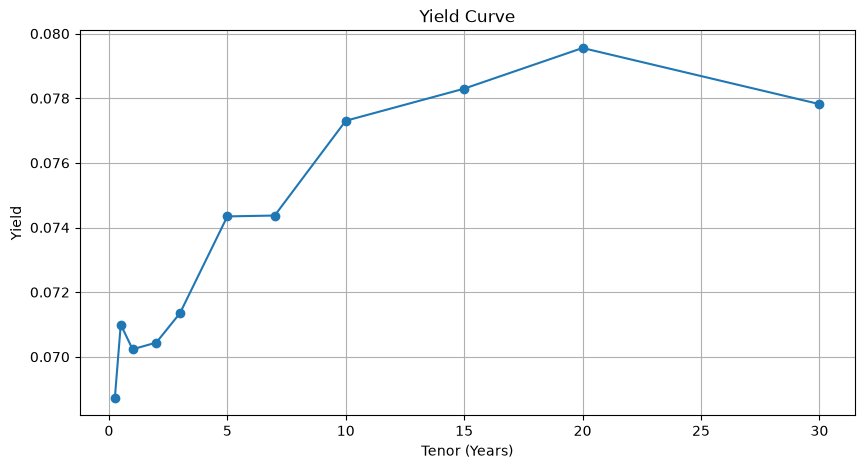

In [14]:
plt.figure(figsize=(10,5))

plt.plot(
    latest_curve["Tenor_Years"],
    latest_curve["Yield"],
    marker="o"
)

plt.title("Yield Curve")
plt.xlabel("Tenor (Years)")
plt.ylabel("Yield")

plt.grid(True)

plt.show()

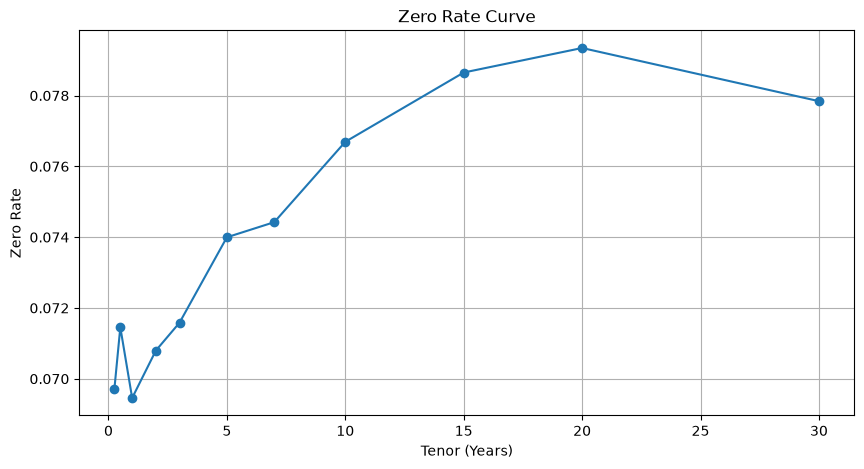

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    latest_curve["Tenor_Years"],
    latest_curve["ZeroRate"],
    marker="o"
)

plt.title("Zero Rate Curve")
plt.xlabel("Tenor (Years)")
plt.ylabel("Zero Rate")

plt.grid(True)

plt.show()

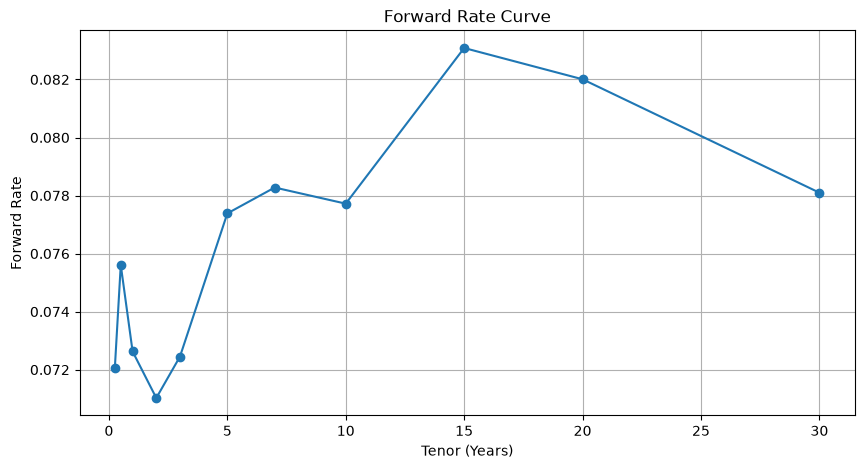

In [16]:
plt.figure(figsize=(10,5))

plt.plot(
    latest_curve["Tenor_Years"],
    latest_curve["ForwardRate"],
    marker="o"
)

plt.title("Forward Rate Curve")
plt.xlabel("Tenor (Years)")
plt.ylabel("Forward Rate")

plt.grid(True)

plt.show()

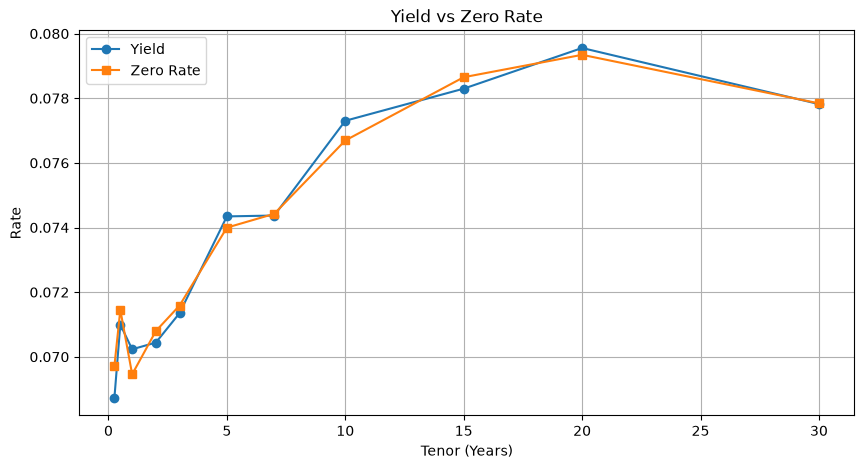

In [17]:
plt.figure(figsize=(10,5))

plt.plot(
    latest_curve["Tenor_Years"],
    latest_curve["Yield"],
    marker="o",
    label="Yield"
)

plt.plot(
    latest_curve["Tenor_Years"],
    latest_curve["ZeroRate"],
    marker="s",
    label="Zero Rate"
)

plt.legend()

plt.title("Yield vs Zero Rate")
plt.xlabel("Tenor (Years)")
plt.ylabel("Rate")

plt.grid(True)

plt.show()

In [18]:
print(f"Latest Curve Date: {latest_date}")

print(
    f"Shortest Maturity Yield: "
    f"{latest_curve['Yield'].iloc[0]:.2%}"
)

print(
    f"Longest Maturity Yield: "
    f"{latest_curve['Yield'].iloc[-1]:.2%}"
)

Latest Curve Date: 2024-10-30
Shortest Maturity Yield: 6.87%
Longest Maturity Yield: 7.78%
